# 1-D VES Forward Modelling

**Vertical Electrical Sounding (VES)** is an electrical geophysical method used to image the shallow subsurface resistivity structure (typically < 1 km depth). A direct current $I$ is injected via two current electrodes (A, B) and the resulting potential difference $V_{MN}$ is measured across two potential electrodes (M, N). The apparent resistivity is:

$$\rho_a = \frac{V_{MN}}{I} \cdot K$$

where $K$ is the **geometric factor** that depends on the electrode configuration.

## Schlumberger Array

This library uses the **Schlumberger** array, where the potential electrode spacing $a = MN$ is kept small relative to the current electrode half-spacing $b = \text{AB}/2$:

$$\rho_a \approx \frac{V_{MN}}{I}\,\pi\,\frac{b^2}{a}, \qquad a \ll b$$

## Forward Modelling via the Linear Filter Method

For a 1-D layered earth, the apparent resistivity at electrode half-spacing $r = \text{AB}/2$ is (Stefanescu's equation):

$$\rho_a(r) = r^2 \int_0^\infty T(\lambda)\,J_1(r\lambda)\,\lambda\,d\lambda$$

where $J_1$ is the first-order Bessel function and $T(\lambda)$ is the **resistivity transform**, computed recursively from the deepest layer ($T_N = \rho_N$) upward:

$$T_i(\lambda) = \rho_i\,\frac{\left(1 - e^{-2\lambda h_i}\right) + \dfrac{T_{i+1}}{\rho_i}\left(1 + e^{-2\lambda h_i}\right)}{\left(1 + e^{-2\lambda h_i}\right) + \dfrac{T_{i+1}}{\rho_i}\left(1 - e^{-2\lambda h_i}\right)}$$

The Hankel transform integral is evaluated efficiently using **Ghosh's digital filter** (Guptasarma coefficients). Available options: `'guptasarma_7'`, `'guptasarma_11'`, `'guptasarma_22'`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Load Observed Data

Load the field data from `VES4.csv`. The relevant columns are:
- `L/2 (m)` — current electrode half-spacing AB/2
- `ρa (Ωm)` — measured apparent resistivity

In [2]:
data = pd.read_csv(r"C:\Users\pamcl\Downloads\VES4.csv").dropna()

ab2       = data['L/2 (m)'].values    # AB/2  [m]
rhoap_obs = data['ρa (Ωm)'].values    # observed apparent resistivity  [ohm.m]

print(f'Loaded {len(ab2)} data points')
print(f'AB/2 range  : {ab2.min():.1f} m  to  {ab2.max():.0f} m')
print(f'rho_a range : {rhoap_obs.min():.0f}  to  {rhoap_obs.max():.0f}  ohm.m')
data

Loaded 39 data points
AB/2 range  : 1.0 m  to  1800 m
rho_a range : 68  to  786  ohm.m


,Nr,A/2 (m),L/2 (m),U (mV),I (mA),ρa (Ωm),Error (%)
0,1,0.1,1.0,1,1,375,1
1,2,0.1,1.5,1,1,500,1
2,3,0.1,2.0,1,1,635,1
3,4,0.1,3.0,1,1,726,1
4,5,0.1,3.0,1,1,678,1
5,6,0.1,4.0,1,1,786,1
6,7,0.1,5.0,1,1,763,1
7,8,0.1,6.0,1,1,733,1
8,9,0.1,6.0,1,1,677,1
9,10,0.1,8.0,1,1,553,1


## 2. Earth Model

Specify the synthetic 1-D layered earth:

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| `rhotr`   | $\rho_1,\dots,\rho_N$ | True resistivity of each layer $[\Omega\cdot\text{m}]$, length $N$ |
| `thick`   | $h_1,\dots,h_{N-1}$   | Thickness of each layer $[\text{m}]$, length $N-1$ (deepest layer is a half-space) |

Modify these values to explore different geological scenarios.

In [3]:
# True resistivities of each layer [ohm.m]  (N layers)
rhotr = np.array([300, 500, 20])

# Thickness of each layer [m]  (N-1 values; deepest layer is a half-space)
thick = np.array([20, 20])

# Ghosh digital filter
filter_coeff = 'guptasarma_7'   # 'guptasarma_7' | 'guptasarma_11' | 'guptasarma_22'

# ── Electrode geometry ────────────────────────────────────────────────────────
# 'schlumberger'  : spacing = AB/2 [m]  (VES4.csv 'L/2' column)
#                   K = pi * (AB/2)^2 / MN   (J1 Hankel transform, Guptasarma filter)
# 'wenner'        : spacing = electrode spacing a [m]  (A-M-N-B, equal a)
#                   K = 2*pi*a                (J0 Hankel transform, numerical)
# 'dipole-dipole' : spacing = dipole length a [m], separation factor n_dd
#                   K = pi*n*(n+1)*(n+2)*a   (J0 Hankel transform, numerical)
geometry = 'schlumberger'
n_dd = 1   # separation factor, only used for dipole-dipole

print(f'Layers        : {len(rhotr)}')
print(f'Resistivities : {rhotr}  ohm.m')
print(f'Thicknesses   : {thick}  m')
print(f'Geometry      : {geometry}')
print(f'Filter        : {filter_coeff}')

Layers        : 3
Resistivities : [300 500  20]  ohm.m
Thicknesses   : [20 20]  m
Geometry      : schlumberger
Filter        : guptasarma_7


## 3. Compute and Visualise the Forward Response

`ves_forward` applies the recursive resistivity transform and the Ghosh digital filter to compute $\rho_a$ at each AB/2 value. The two panels show:

- **Left** — the computed forward response overlaid on the observed data from VES4.csv
- **Right** — the earth model as a resistivity–depth step function

In [4]:
from scipy.integrate import quad
from scipy.special import j0 as J0

def ves_forward(spacing, rhotr, thick, filter_coeff='guptasarma_7',
                geometry='schlumberger', n_dd=1):
    """
    1-D VES forward model using Ghosh's linear filter method (Suriyapor 2020 §2.1).

    For all geometries the resistivity transform T(λ) is computed recursively
    bottom-up from the deepest (half-space) layer.  The Hankel transform
    integral is then evaluated by:
      • Schlumberger — fast Guptasarma J1 digital filter
      • Wenner / Dipole-Dipole — scipy numerical J0 integration

    Parameters
    ----------
    spacing      : 1-D array  electrode spacing [m]; meaning depends on geometry
    rhotr        : 1-D array  true resistivities [ohm.m], length N
    thick        : 1-D array  layer thicknesses [m], length N-1
    filter_coeff : str        'guptasarma_7' | 'guptasarma_11' | 'guptasarma_22'
    geometry     : str        'schlumberger' | 'wenner' | 'dipole-dipole'
    n_dd         : int        dipole-dipole separation factor (default 1)

    Returns
    -------
    rhoap : 1-D array  apparent resistivity [ohm.m]
    """
    n_layers = len(rhotr)

    # ── Recursive resistivity transform T(λ) — shared by all geometries ───────
    def T_lambda(lam):
        T = float(rhotr[-1])
        for k in range(n_layers - 2, -1, -1):
            exp2     = np.exp(-2.0 * lam * thick[k])
            tanh_val = (1.0 - exp2) / (1.0 + exp2)      # tanh(λ·hk)
            T = rhotr[k] * (T + rhotr[k] * tanh_val) / (rhotr[k] + T * tanh_val)
        return T

    # ── Schlumberger — Guptasarma J1 digital filter (fast) ────────────────────
    if geometry == 'schlumberger':
        if filter_coeff == 'guptasarma_7':
            a   = np.array([-0.17445,  0.09672,  0.36789,  0.63906,
                              0.91023,  1.18140,  1.45257])
            phi = np.array([ 0.1732,   0.2945,   2.1470,  -2.1733,
                              0.6646,  -0.1215,   0.0155])
        elif filter_coeff == 'guptasarma_11':
            a   = np.array([-0.420625, -0.202656,  0.015313,  0.233281,
                              0.451250,  0.669219,  0.887188,  1.105156,
                              1.323125,  1.541094,  1.759063])
            phi = np.array([ 0.041873, -0.022258,  0.387660,  0.647103,
                              1.848730, -2.960840,  1.358412, -0.377590,
                              0.097107, -0.024243,  0.004046])
        elif filter_coeff == 'guptasarma_22':
            a   = np.array([-0.980685, -0.771995, -0.563305, -0.354615,
                             -0.145925,  0.062765,  0.271455,  0.480145,
                              0.688835,  0.897525,  1.106215,  1.314905,
                              1.523595,  1.732285,  1.940975,  2.149665,
                              2.358355,  2.567045,  2.775735])
            phi = np.array([ 0.00097112, -0.00102152,  0.00906965,  0.01404316,
                              0.09012000,  0.30171582,  0.99627084,  1.36908320,
                             -2.99681171,  1.65463068, -0.59399277,  0.22329813,
                             -0.10119309,  0.05186135, -0.02748647,  0.01384932,
                             -0.00599074,  0.00190463, -0.00032160])
        else:
            raise ValueError(f"Unknown filter_coeff '{filter_coeff}'.")

        def _schlumberger(L):
            return sum(T_lambda(10.0 ** (a_i - np.log10(L))) * phi_i
                       for a_i, phi_i in zip(a, phi))

        return np.array([_schlumberger(L) for L in spacing])

    # ── Wenner — numerical J0 integration ─────────────────────────────────────
    # K = 2πa;  ρ_a = 2a ∫₀^∞ T(λ)(J₀(aλ) − J₀(2aλ)) dλ
    elif geometry == 'wenner':
        def _wenner(a):
            lam_max = 60.0 / a       # safely beyond oscillations
            val, _ = quad(
                lambda lam: T_lambda(lam) * (J0(a * lam) - J0(2 * a * lam)),
                0, lam_max, limit=300, epsabs=1e-6, epsrel=1e-6
            )
            return 2 * a * val

        return np.array([_wenner(a) for a in spacing])

    # ── Dipole-Dipole — numerical J0 integration ───────────────────────────────
    # K = π·n·(n+1)·(n+2)·a
    # ρ_a = n(n+1)(n+2)a/2 · ∫₀^∞ T(λ)[2J₀((n+1)aλ)−J₀(naλ)−J₀((n+2)aλ)] dλ
    elif geometry == 'dipole-dipole':
        n = n_dd

        def _dd(a):
            lam_max = 60.0 / (n * a)
            val, _ = quad(
                lambda lam: T_lambda(lam) * (
                    2 * J0((n + 1) * a * lam)
                    - J0(n * a * lam)
                    - J0((n + 2) * a * lam)
                ),
                0, lam_max, limit=300, epsabs=1e-6, epsrel=1e-6
            )
            return n * (n + 1) * (n + 2) * a / 2 * val

        return np.array([_dd(a) for a in spacing])

    else:
        raise ValueError(f"Unknown geometry '{geometry}'. "
                         "Choose 'schlumberger', 'wenner', or 'dipole-dipole'.")

print('ves_forward defined  (geometries: schlumberger | wenner | dipole-dipole)')

ves_forward defined  (geometries: schlumberger | wenner | dipole-dipole)


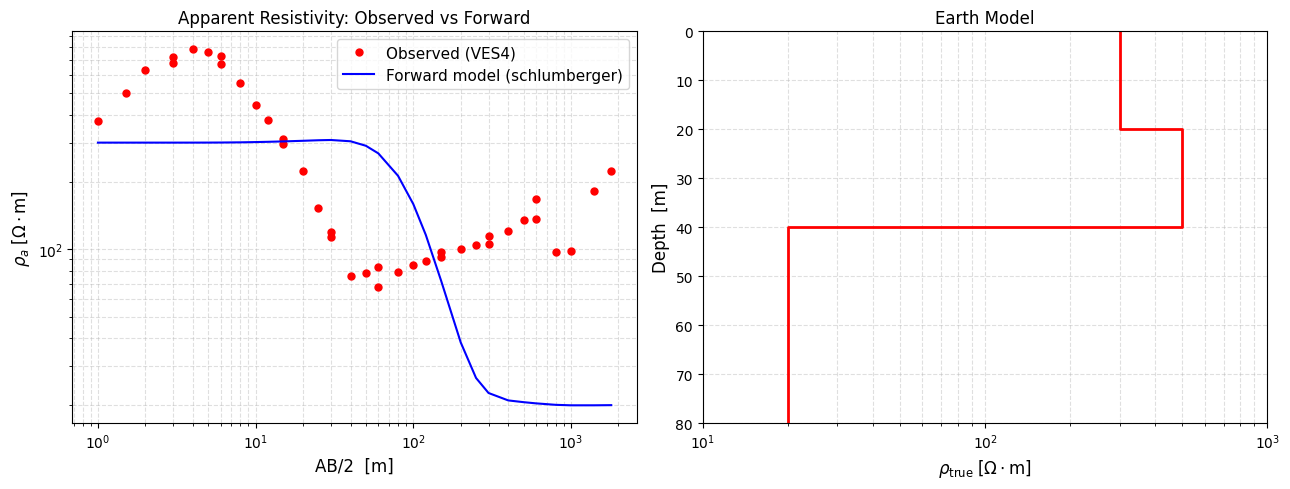

In [5]:
rhoap_cal = ves_forward(ab2, rhotr, thick,
                        filter_coeff=filter_coeff,
                        geometry=geometry, n_dd=n_dd)

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(ab2, rhoap_obs, 'ro', markersize=5, label='Observed (VES4)')
axes[0].loglog(ab2, rhoap_cal, 'b-', linewidth=1.5,
               label=f'Forward model ({geometry})')
axes[0].set_xlabel(r'AB/2  [m]', fontsize=12)
axes[0].set_ylabel(r'$\rho_a\;[\Omega\cdot\mathrm{m}]$', fontsize=12)
axes[0].set_title('Apparent Resistivity: Observed vs Forward', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, which='both', linestyle='--', alpha=0.4)

z_tops = np.concatenate([[0], np.cumsum(thick)])
z_max  = z_tops[-1] * 2
z_step, rho_step = [], []
for i in range(len(rhotr)):
    z_step.append(z_tops[i])
    rho_step.append(rhotr[i])
    if i < len(rhotr) - 1:
        z_step.append(z_tops[i + 1])
        rho_step.append(rhotr[i])
z_step.append(z_max)
rho_step.append(rhotr[-1])

axes[1].plot(rho_step, z_step, 'r-', linewidth=2)
axes[1].set_xscale('log')
axes[1].invert_yaxis()
axes[1].set_xlim([min(rhotr) * 0.5, max(rhotr) * 2])
axes[1].set_ylim([z_max, 0])
axes[1].set_xlabel(r'$\rho_{\mathrm{true}}\;[\Omega\cdot\mathrm{m}]$', fontsize=12)
axes[1].set_ylabel('Depth  [m]', fontsize=12)
axes[1].set_title('Earth Model', fontsize=12)
axes[1].grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 4. Inversion

Two complementary inversion approaches are provided:

### 4a. Blocky inversion — free layer boundaries
L-BFGS-B minimises the RMS misfit in log₁₀ space over both resistivities and thicknesses (all parameters free). Set `n_opt` to the desired number of layers.

### 4b. Smooth inversion — fixed depths, roughness regularisation (Occam-style)
The subsurface is discretised into `n_smooth` thin layers with log-spaced fixed depths. Only the resistivities are inverted for, subject to a smoothness penalty (first-difference roughness operator):

$$\Phi = \text{RMS}_{\text{data}} + \lambda \cdot \|\mathbf{R}\,\log_{10}\boldsymbol{\rho}\|^2$$

where $\mathbf{R}$ is the first-difference roughness matrix and $\lambda$ (`lam_smooth`) controls the trade-off between data fit and model smoothness.

[Blocky]  Converged=True   RMS=0.05396
          ρ = [   74.2   832.5    72.8   125.5 50000. ]  ohm.m
          h = [1.0000e-01 5.4000e+00 5.7800e+01 1.0635e+03]  m

[Smooth]  Converged=True   RMS=0.04301  (λ=0.01, 40 layers)


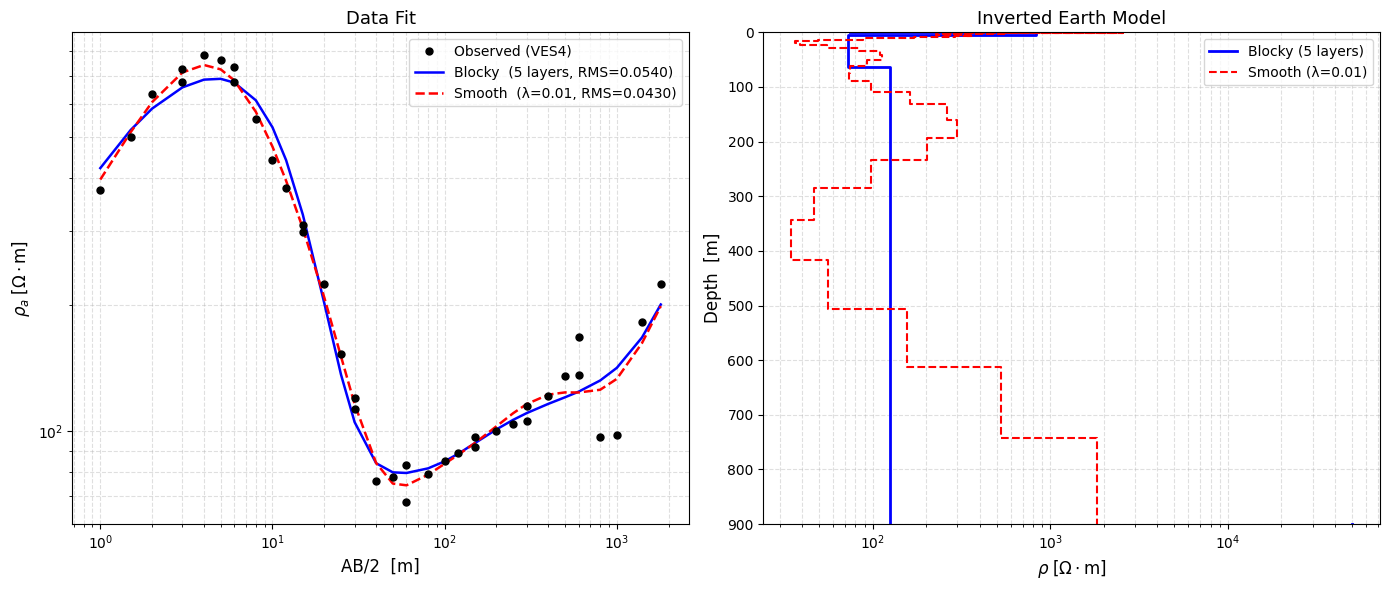

In [ ]:
from scipy.optimize import minimize

def _rms_log(obs, pred):
    return np.sqrt(np.mean((np.log10(pred) - np.log10(obs)) ** 2))

# ═══════════════════════════════════════════════════════════════════════════════
# 4a.  BLOCKY INVERSION  — free resistivities + free thicknesses
# ═══════════════════════════════════════════════════════════════════════════════
n_opt = 5   # number of layers (adjust freely)

def objective_blocky(params_log):
    rhotr_opt = np.exp(params_log[:n_opt])
    thick_opt = np.exp(params_log[n_opt:])
    try:
        pred = ves_forward(ab2, rhotr_opt, thick_opt,
                           filter_coeff=filter_coeff,
                           geometry=geometry, n_dd=n_dd)
        return _rms_log(rhoap_obs, pred)
    except Exception:
        return 1e10

rhotr0  = np.full(n_opt, np.median(rhoap_obs))
thick0  = np.logspace(np.log10(0.5 * ab2.min()),
                      np.log10(0.15 * ab2.max()), n_opt - 1)
x0_b    = np.concatenate([np.log(rhotr0), np.log(thick0)])
bounds_b = ([(np.log(0.1), np.log(50000))] * n_opt +
            [(np.log(1.0), np.log(5000))]  * (n_opt - 1))   # min thickness 1 m

res_b   = minimize(objective_blocky, x0_b, method='L-BFGS-B', bounds=bounds_b,
                   options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-10})
rhotr_b = np.exp(res_b.x[:n_opt])
thick_b = np.exp(res_b.x[n_opt:])
pred_b  = ves_forward(ab2, rhotr_b, thick_b,
                       filter_coeff=filter_coeff, geometry=geometry, n_dd=n_dd)
rms_b   = _rms_log(rhoap_obs, pred_b)
print(f'[Blocky]  Converged={res_b.success}   RMS={rms_b:.5f}')
print(f'          ρ = {np.round(rhotr_b, 1)}  ohm.m')
print(f'          h = {np.round(thick_b, 1)}  m')

# ═══════════════════════════════════════════════════════════════════════════════
# 4b.  SMOOTH INVERSION  — fixed log-spaced depths, roughness regularisation
# ═══════════════════════════════════════════════════════════════════════════════
n_smooth   = 40    # number of fixed thin layers  (more → finer depth resolution)
lam_smooth = 0.01  # regularisation strength  (larger → smoother, smaller → sharper)
#   Typical range: 0.001 (sharp) … 0.1 (very smooth)

# Fixed layer thicknesses: log-spaced from 0.5 m down to ~half the max AB/2
thick_fixed = np.diff(np.concatenate([
    [0],
    np.logspace(np.log10(0.5), np.log10(ab2.max() * 0.5), n_smooth)
]))

# First-difference roughness matrix R  (shape: n_smooth-1 × n_smooth)
R = np.zeros((n_smooth - 1, n_smooth))
for j in range(n_smooth - 1):
    R[j, j] = -1;  R[j, j + 1] = 1

def objective_smooth(log_rho):
    rhotr_s = np.exp(log_rho)
    try:
        pred      = ves_forward(ab2, rhotr_s, thick_fixed,
                                filter_coeff=filter_coeff,
                                geometry=geometry, n_dd=n_dd)
        data_fit  = _rms_log(rhoap_obs, pred)
        roughness = np.sqrt(np.mean((R @ log_rho) ** 2))
        return data_fit + lam_smooth * roughness
    except Exception:
        return 1e10

log_rho0 = np.full(n_smooth, np.log(np.median(rhoap_obs)))
bounds_s = [(np.log(0.1), np.log(50000))] * n_smooth

res_s   = minimize(objective_smooth, log_rho0, method='L-BFGS-B', bounds=bounds_s,
                   options={'maxiter': 10000, 'ftol': 1e-14, 'gtol': 1e-10})
rhotr_s = np.exp(res_s.x)
pred_s  = ves_forward(ab2, rhotr_s, thick_fixed,
                       filter_coeff=filter_coeff, geometry=geometry, n_dd=n_dd)
rms_s   = _rms_log(rhoap_obs, pred_s)
print(f'\n[Smooth]  Converged={res_s.success}   RMS={rms_s:.5f}  (λ={lam_smooth}, {n_smooth} layers)')

# ═══════════════════════════════════════════════════════════════════════════════
# Plot both results side by side
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: sounding curves ──────────────────────────────────────────────────────
axes[0].loglog(ab2, rhoap_obs, 'ko', markersize=5, zorder=5, label='Observed (VES4)')
axes[0].loglog(ab2, pred_b, 'b-',  linewidth=1.8,
               label=f'Blocky  ({n_opt} layers, RMS={rms_b:.4f})')
axes[0].loglog(ab2, pred_s, 'r--', linewidth=1.8,
               label=f'Smooth  (λ={lam_smooth}, RMS={rms_s:.4f})')
axes[0].set_xlabel(r'AB/2  [m]', fontsize=12)
axes[0].set_ylabel(r'$\rho_a\;[\Omega\cdot\mathrm{m}]$', fontsize=12)
axes[0].set_title('Data Fit', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.4)

# ── Right: earth models ────────────────────────────────────────────────────────
z_max_plot = np.sum(thick_fixed)

# blocky — step function from free depths
z_b = np.concatenate([[0], np.cumsum(thick_b)])
zs_b, rs_b = [], []
for i in range(n_opt):
    zs_b.append(z_b[i]);         rs_b.append(rhotr_b[i])
    if i < n_opt - 1:
        zs_b.append(z_b[i + 1]); rs_b.append(rhotr_b[i])
zs_b.append(z_max_plot);  rs_b.append(rhotr_b[-1])
axes[1].plot(rs_b, zs_b, 'b-', linewidth=2, label=f'Blocky ({n_opt} layers)')

# smooth — step function from fixed depths
z_s = np.concatenate([[0], np.cumsum(thick_fixed)])
zs_s, rs_s = [], []
for i in range(n_smooth):
    zs_s.append(z_s[i]);         rs_s.append(rhotr_s[i])
    zs_s.append(z_s[i + 1]);     rs_s.append(rhotr_s[i])
axes[1].plot(rs_s, zs_s, 'r--', linewidth=1.5, label=f'Smooth (λ={lam_smooth})')

axes[1].set_xscale('log')
axes[1].invert_yaxis()
axes[1].set_ylim([z_max_plot, 0])
axes[1].set_xlabel(r'$\rho\;[\Omega\cdot\mathrm{m}]$', fontsize=12)
axes[1].set_ylabel('Depth  [m]', fontsize=12)
axes[1].set_title('Inverted Earth Model', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()